# SC2079 symbol card detection (YOLO26)

Fine-tunes a pretrained YOLO26-nano detector to localize and classify the 30 symbol cards (image IDs 11–40).

Pipeline:
1. Capture images with `photobooth.py` into `dataset/{train,test}/<id>_<slug>/` (auto-labels each shot with a YOLO sidecar).
2. Run `autolabel.py` to build `dataset_yolo/` (images + labels + `data.yaml`), then skim `dataset_yolo/review/` for bad boxes.
3. Train, validate and export below.

Setup: `uv pip install -p .venv ultralytics` (pulls in torch, opencv, matplotlib).

In [1]:
import random
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device

'mps'

In [2]:
ROOT = Path.cwd()
YOLO_DATASET = ROOT / "dataset_yolo"
DATA_YAML = YOLO_DATASET / "data.yaml"

# rebuild labels + data.yaml from the ImageFolder captures in dataset/
# (skips already-labeled images; use --force to redo everything)
!{sys.executable} autolabel.py

train/ -> train/
  labeled 0 (sidecar 0, fallback-box 0), skipped 1, failed 0
test/ -> val/
  labeled 0 (sidecar 0, fallback-box 0), skipped 0, failed 0
val split is empty (no dataset/test captures yet) - data.yaml will validate on train
Wrote /Users/pingw/projects/SC2079-MULTIDISCIPLINARY-DES-PROJ/image-rec/dataset_yolo/data.yaml
Review images (boxes drawn) in /Users/pingw/projects/SC2079-MULTIDISCIPLINARY-DES-PROJ/image-rec/dataset_yolo/review


### Dataset sanity check

Every image needs a matching label file; class distribution should be roughly balanced. Augmentation (rotation, scale, perspective, HSV jitter, mosaic) is applied on the fly by Ultralytics during training, so we don't pre-generate transformed copies.

In [3]:
import yaml

names = yaml.safe_load(DATA_YAML.read_text())["names"]

for split in ("train", "val"):
    images = sorted(p for p in (YOLO_DATASET / "images" / split).glob("*") if p.is_file())
    labels = {p.stem: p for p in (YOLO_DATASET / "labels" / split).glob("*.txt")}
    missing = [p.name for p in images if p.stem not in labels]
    print(f"{split}: {len(images)} images, {len(labels)} labels"
          + (f", MISSING labels for {missing}" if missing else ""))
    counts = Counter(int(p.read_text().split()[0]) for p in labels.values())
    for cls_index in sorted(counts):
        print(f"    {names[cls_index]:<10} {counts[cls_index]}")

train: 1 images, 1 labels
    11_1       1
val: 0 images, 0 labels


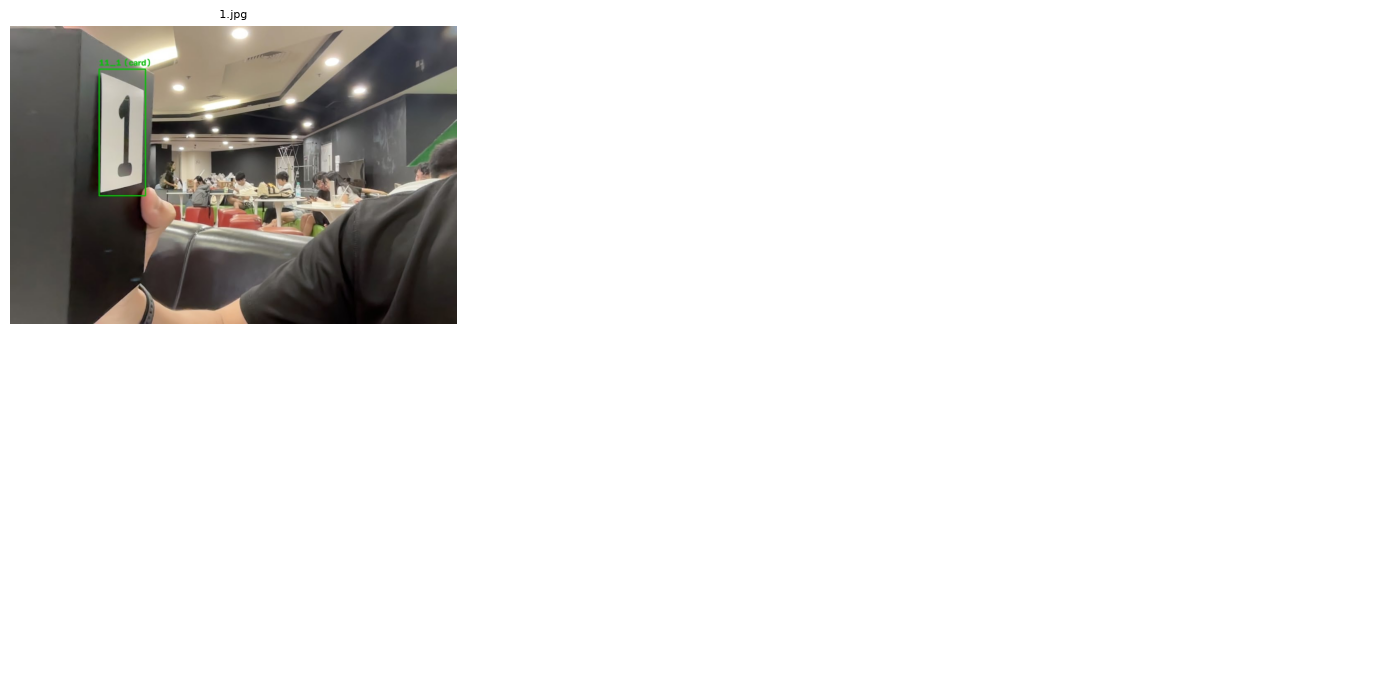

In [4]:
# spot-check auto-generated boxes (green = card outline, orange = fallback)
review = sorted((YOLO_DATASET / "review" / "train").glob("*.jpg"))
sample = random.sample(review, min(6, len(review)))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax in axes.flat:
    ax.axis("off")
for ax, path in zip(axes.flat, sample):
    ax.imshow(cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB))
    ax.set_title(path.name, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
model = YOLO("yolo26n.pt")  # detection task, pretrained on COCO

# heavier on-the-fly augmentation to stretch the small dataset: every epoch the
# model sees a freshly rotated/shifted/scaled/sheared/color-jittered version of
# each capture, so the effective number of distinct training examples scales
# with epochs. fliplr stays 0: mirroring turns digits and the left/right
# arrow cards into the wrong class.
#
# The whole network trains (no freeze): COCO backbone features can't separate
# printed digits, so the backbone must adapt.
results = model.train(
    data=DATA_YAML,
    epochs=80,
    imgsz=640,
    batch=16,
    degrees=20,       # rotation
    translate=0.2,    # shift up to 20% of the frame
    scale=0.6,        # zoom in/out
    shear=10,         # shear angle
    perspective=0.0005,
    hsv_v=0.5,        # brightness jitter (lighting varies on the robot)
    mixup=0.15,       # blend pairs of images
    fliplr=0.0,       # NO horizontal flip (see above)
    device=device,
    seed=42,
    project=ROOT / "runs",   # keep runs in this repo regardless of global yolo settings
)
BEST = Path(results.save_dir) / "weights" / "best.pt"
BEST

### Evaluate and demo

Validation metrics on the held-out split, then a visual check: run the trained detector on sample images and draw its predicted boxes.

In [6]:
model = YOLO(BEST)
metrics = model.val(data=DATA_YAML, device=device, project=ROOT / "runs")
print(f"mAP50: {metrics.box.map50:.3f}   mAP50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.14.0 MPS (Apple M2)
YOLO26n summary (fused): 120 layers, 2,380,686 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 277.7±0.0 MB/s, size: 60.1 KB)
val: Scanning /Users/pingw/projects/SC2079-MULTIDISCIPLINARY-DES-PROJ/image-rec/dataset_yolo/labels/train.cache... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 466.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.0it/s 0.1s
                   all          1          1          0          0          0          0
                  11_1          1          1          0          0          0          0
Speed: 1.1ms preprocess, 130.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /Users/pingw/projects/SC2079-MULTIDISCIPLINARY-DES-PROJ/image-rec/runs/val
mAP50: 0.000   mAP50-95: 0.000


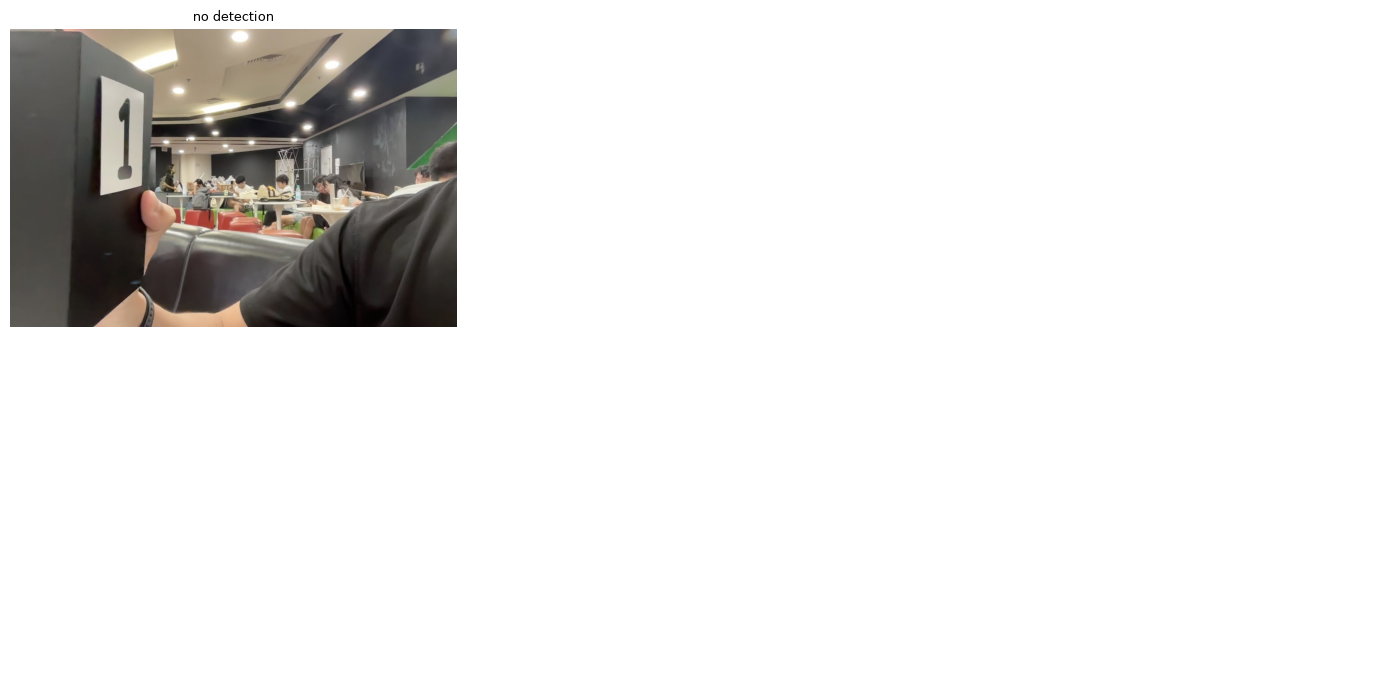

In [7]:
# predicted bounding boxes on sample validation images (falls back to train if val is empty)
val_images = sorted((YOLO_DATASET / "images" / "val").glob("*")) or sorted(
    (YOLO_DATASET / "images" / "train").glob("*")
)
sample = random.sample(val_images, min(6, len(val_images)))
predictions = model.predict([str(p) for p in sample], imgsz=640, device=device, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax in axes.flat:
    ax.axis("off")
for ax, res in zip(axes.flat, predictions):
    ax.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    detected = [model.names[int(c)] for c in res.boxes.cls]
    ax.set_title(", ".join(detected) or "no detection", fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
# snapshot the deployment weights for server.py
# prediction class -> image ID for the task: image_id = int(model.names[cls].split("_")[0])
import shutil

deployed = ROOT / "weights" / "best.pt"
deployed.parent.mkdir(exist_ok=True)
shutil.copy2(BEST, deployed)
print(f"copied {BEST} -> {deployed}")

copied /Users/pingw/projects/SC2079-MULTIDISCIPLINARY-DES-PROJ/image-rec/runs/train/weights/best.pt -> /Users/pingw/projects/SC2079-MULTIDISCIPLINARY-DES-PROJ/image-rec/weights/best.pt
